# E-commerce Customer Segmentation and Prediction


**Key Steps**
1. Data Loading and Exploration
2. Data Cleaning and Preprocessing
3. Exploratory Data Analysis (EDA)
4. RFM Feature Engineering
5. Feature Scaling
6. Finding the Optimal Number of Clusters
7. Algorithm Comparison (K-Means, Hierarchical, DBSCAN, GMM)
8. Best Algorithm Selection
9. Customer Segment Profiling
10. Business Recommendations
11. Save Model and Artifacts


##  Imports and Setup

In [8]:
import warnings
warnings.filterwarnings('ignore')
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

import joblib

sns.set_theme(style='whitegrid', palette='husl')
COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
print("Libraries loaded successfully.")


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Libraries loaded successfully.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Data Loading and Exploration


Each row represents one item in an invoice, with 8 columns:
`InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`.


In [5]:
df_raw = pd.read_csv('data.csv', encoding='latin-1')
print(f"Shape: {df_raw.shape}")
df_raw.head()


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [9]:
print("Data Types:")
print(df_raw.dtypes)
print("\nMissing Values:")
print(df_raw.isnull().sum())
print(f"\nCancelled orders (InvoiceNo starts with C): {df_raw['InvoiceNo'].astype(str).str.startswith('C').sum()}")


Data Types:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Cancelled orders (InvoiceNo starts with C): 9288


In [10]:
df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning and Preprocessing

**Steps:**
- Remove cancelled orders (InvoiceNo starts with 'C')
- Drop rows with missing CustomerID
- Remove rows where Quantity <= 0 or UnitPrice <= 0 (returns/adjustments)
- Convert CustomerID to int, InvoiceDate to datetime
- Derive TotalAmount = Quantity × UnitPrice


In [11]:
df = df_raw.copy()

# Remove cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"After removing cancellations: {df.shape}")

# Drop missing CustomerID
df = df.dropna(subset=['CustomerID'])
print(f"After dropping missing CustomerID: {df.shape}")

# Remove non-positive Quantity / UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"After removing Qty/Price <= 0: {df.shape}")

# Type conversions
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

# Derived feature
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print(f"\nFinal clean dataset: {df.shape}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['CustomerID'].nunique()}")
print(f"Unique invoices : {df['InvoiceNo'].nunique()}")


After removing cancellations: (532621, 8)
After dropping missing CustomerID: (397924, 8)
After removing Qty/Price <= 0: (397884, 8)

Final clean dataset: (397884, 9)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers: 4338
Unique invoices : 18532


## 3. Exploratory Data Analysis

Visual exploration of revenue by country and over time.


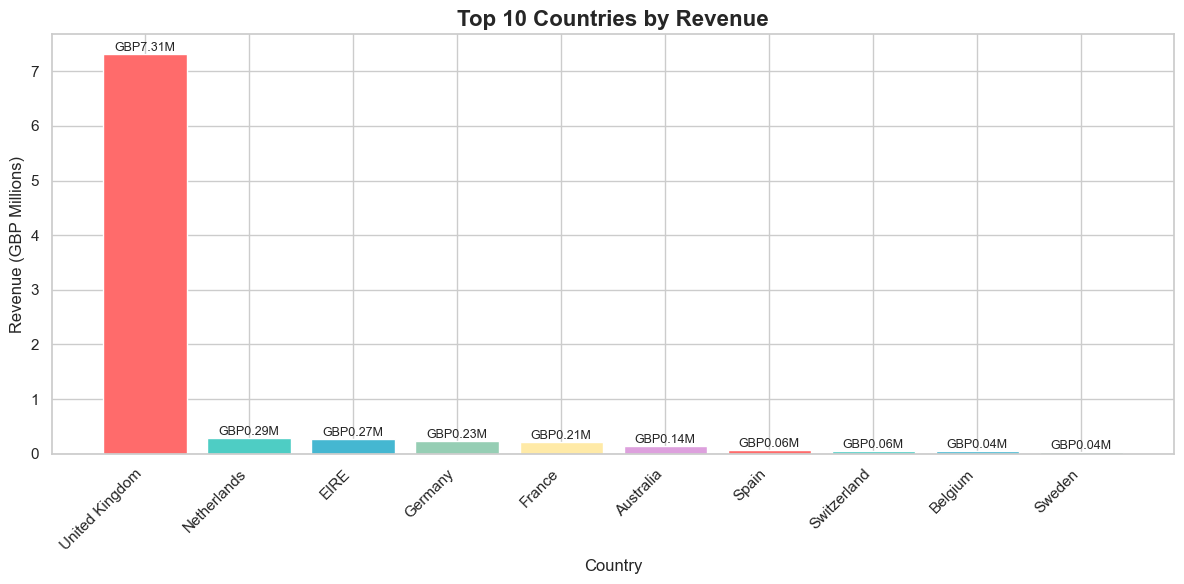

In [12]:
# Top 10 countries by revenue
country_rev = (df.groupby('Country')['TotalAmount']
               .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(country_rev.index, country_rev.values / 1e6, color=COLORS[:len(country_rev)])
ax.set_title('Top 10 Countries by Revenue', fontsize=16, fontweight='bold')
ax.set_xlabel('Country'); ax.set_ylabel('Revenue (GBP Millions)')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, country_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'GBP{val/1e6:.2f}M', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


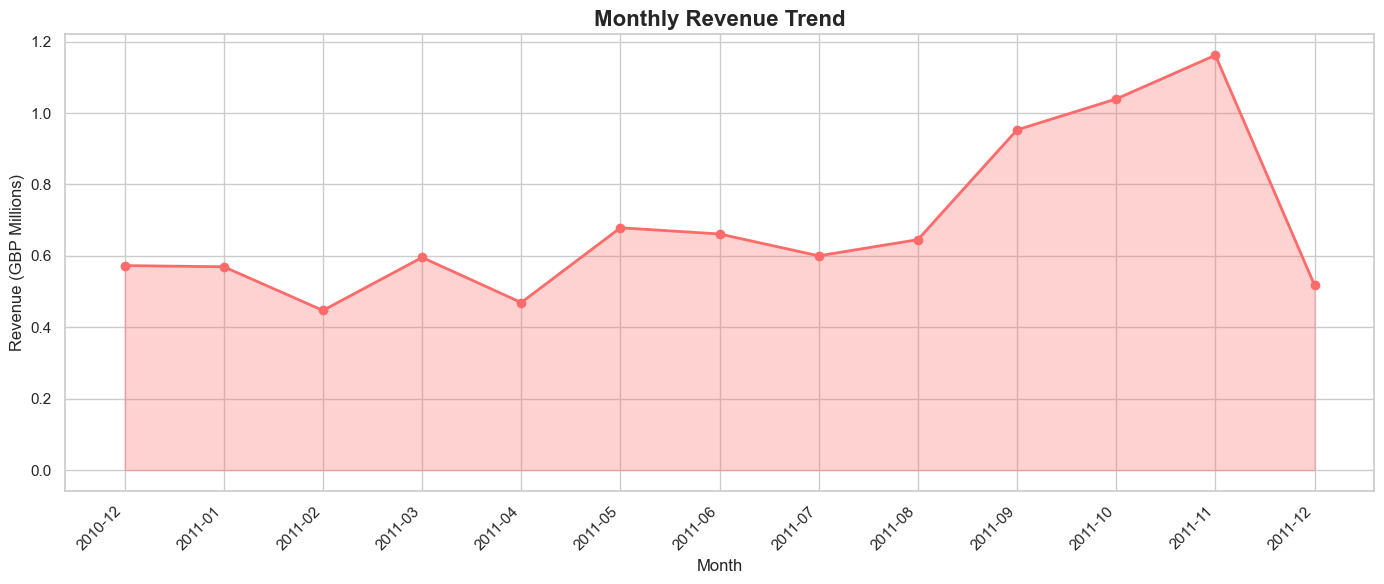

In [13]:
# Monthly revenue trend
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('YearMonth')['TotalAmount'].sum().reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly['YearMonth_str'], monthly['TotalAmount'] / 1e6,
        marker='o', linewidth=2, color='#FF6B6B', markersize=6)
ax.fill_between(monthly['YearMonth_str'], monthly['TotalAmount'] / 1e6,
                alpha=0.3, color='#FF6B6B')
ax.set_title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue (GBP Millions)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


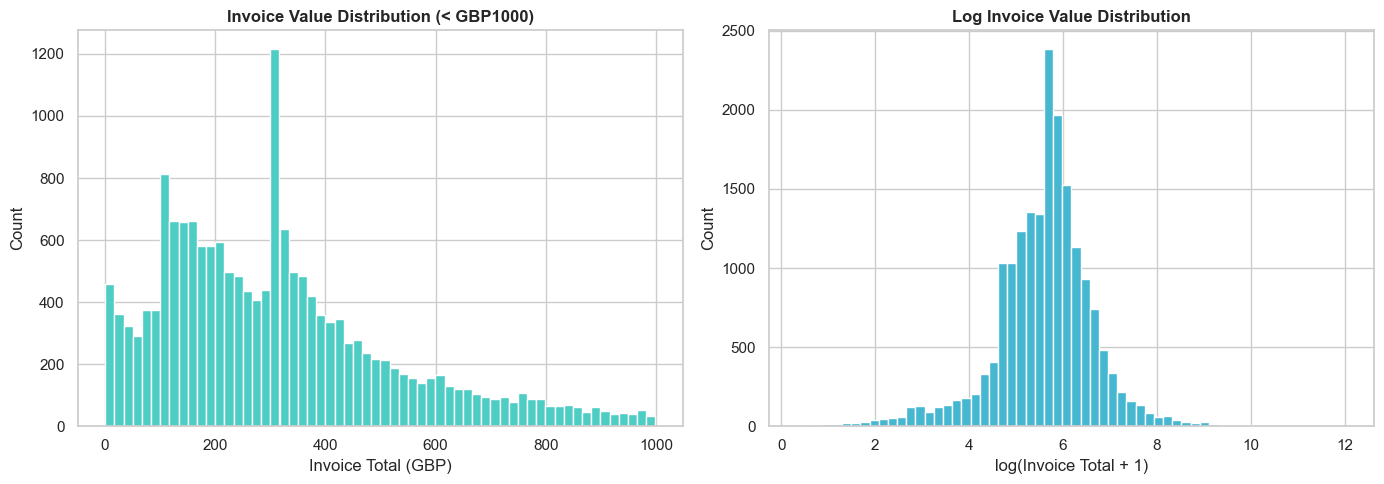

In [14]:
# Invoice value distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
invoice_totals = df.groupby('InvoiceNo')['TotalAmount'].sum()
axes[0].hist(invoice_totals[invoice_totals < 1000], bins=60,
             color='#4ECDC4', edgecolor='white')
axes[0].set_title('Invoice Value Distribution (< GBP1000)', fontweight='bold')
axes[0].set_xlabel('Invoice Total (GBP)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(invoice_totals), bins=60, color='#45B7D1', edgecolor='white')
axes[1].set_title('Log Invoice Value Distribution', fontweight='bold')
axes[1].set_xlabel('log(Invoice Total + 1)')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


## 4. RFM Feature Engineering

**RFM** is a proven framework for customer value analysis:
- **Recency** — days since the customer's most recent purchase (lower = better)
- **Frequency** — number of unique invoices (higher = better)
- **Monetary** — total spend (higher = better)


In [15]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate',  lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',    'nunique'),
    Monetary  = ('TotalAmount',  'sum')
).reset_index()

print(f"RFM table shape: {rfm.shape}")
rfm.describe().round(2)


Reference date: 2011-12-10 12:50:00
RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2054.27
std,1721.81,100.01,7.70,8989.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,307.41
50%,15299.50,51.00,2.00,674.48
75%,16778.75,142.00,5.00,1661.74
max,18287.00,374.00,209.00,280206.02


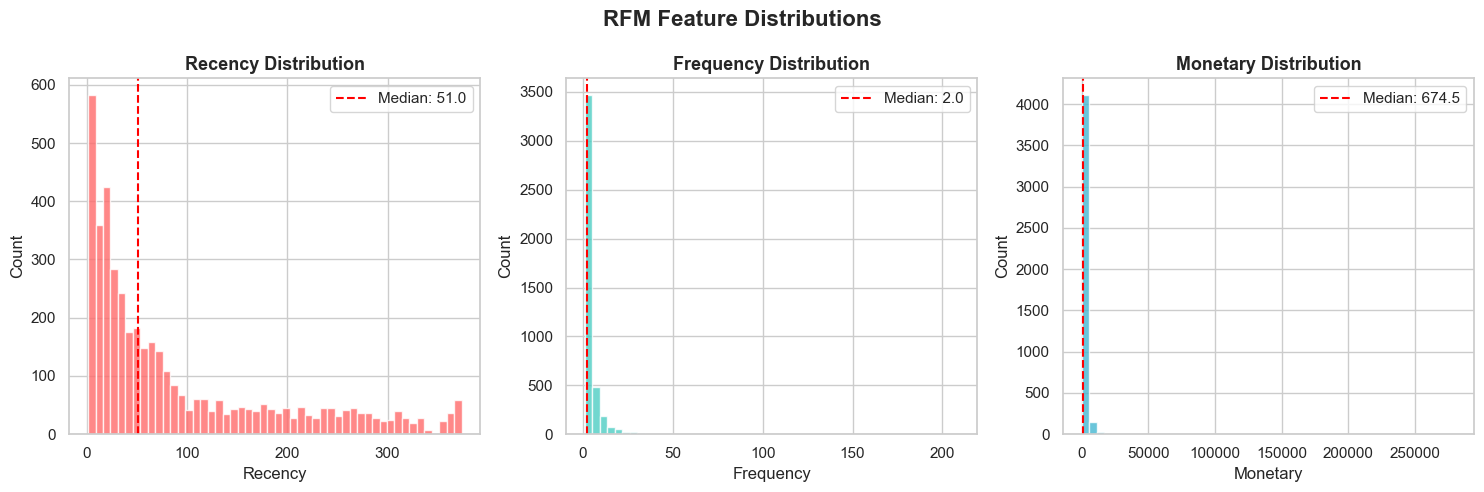

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], COLORS):
    ax.hist(rfm[col], bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Count')
    ax.axvline(rfm[col].median(), color='red', linestyle='--', linewidth=1.5,
               label=f'Median: {rfm[col].median():.1f}')
    ax.legend()
plt.suptitle('RFM Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Feature Scaling

RFM values are heavily right-skewed. We apply **log1p transformation** to reduce skewness,
then **StandardScaler** to ensure all three features have zero mean and unit variance.
This prevents high-magnitude monetary values from dominating the distance calculations.


rfm_scaled shape : (4338, 3)
Column means (~0): [-0. -0.  0.]
Column stds  (~1): [1. 1. 1.]


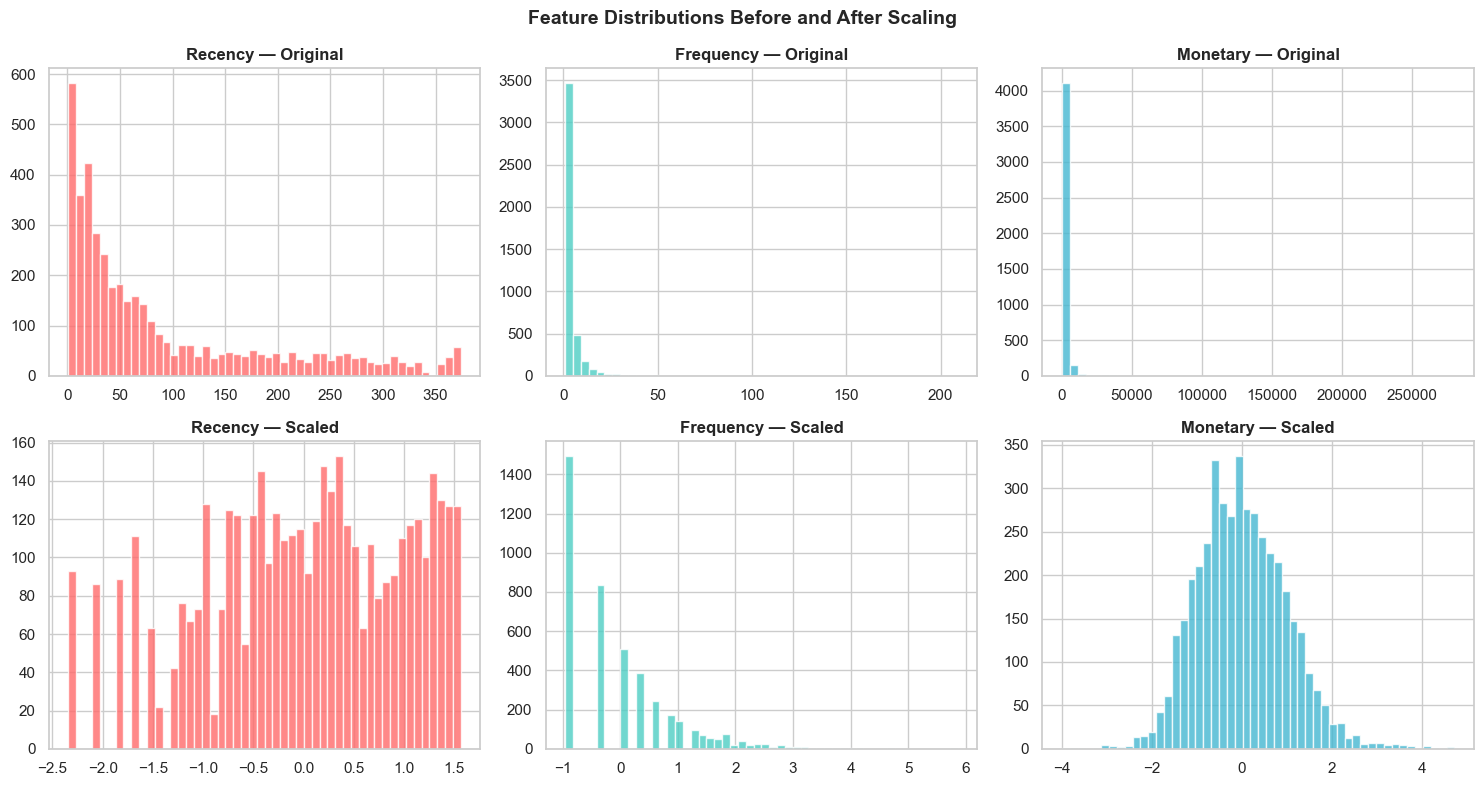

In [17]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Recency']   = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

print(f"rfm_scaled shape : {rfm_scaled.shape}")
print(f"Column means (~0): {rfm_scaled.mean(axis=0).round(4)}")
print(f"Column stds  (~1): {rfm_scaled.std(axis=0).round(4)}")

# Compare distributions before/after scaling
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    axes[0, i].hist(rfm[col], bins=50, color=COLORS[i], edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col} — Original', fontweight='bold')
    axes[1, i].hist(rfm_scaled[:, i], bins=50, color=COLORS[i], edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col} — Scaled', fontweight='bold')
plt.suptitle('Feature Distributions Before and After Scaling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Finding Optimal Number of Clusters

We sweep k=2 to 10 and evaluate four metrics:
- **Inertia** (Elbow method) — measures within-cluster sum of squares; look for the elbow
- **Silhouette Score** (higher is better) — measures cluster cohesion and separation
- **Davies-Bouldin Score** (lower is better) — ratio of within-cluster scatter to between-cluster separation
- **Calinski-Harabasz Score** (higher is better) — ratio of between-cluster to within-cluster dispersion


In [18]:
k_range = range(2, 11)
inertias, silhouettes, db_scores, ch_scores = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))
    db_scores.append(davies_bouldin_score(rfm_scaled, labels))
    ch_scores.append(calinski_harabasz_score(rfm_scaled, labels))
    print(f"k={k:2d}: inertia={km.inertia_:7.0f}  sil={silhouettes[-1]:.4f}  "
          f"db={db_scores[-1]:.4f}  ch={ch_scores[-1]:.0f}")


k= 2: inertia=   6481  sil=0.4329  db=0.8921  ch=4370
k= 3: inertia=   4868  sil=0.3365  db=1.0480  ch=3627
k= 4: inertia=   3939  sil=0.3371  db=1.0101  ch=3329
k= 5: inertia=   3296  sil=0.3161  db=0.9895  ch=3194
k= 6: inertia=   2855  sil=0.3133  db=1.0134  ch=3083
k= 7: inertia=   2549  sil=0.3100  db=0.9726  ch=2964
k= 8: inertia=   2337  sil=0.3008  db=0.9940  ch=2826
k= 9: inertia=   2156  sil=0.2817  db=1.0147  ch=2726
k=10: inertia=   2000  sil=0.2787  db=1.0202  ch=2648


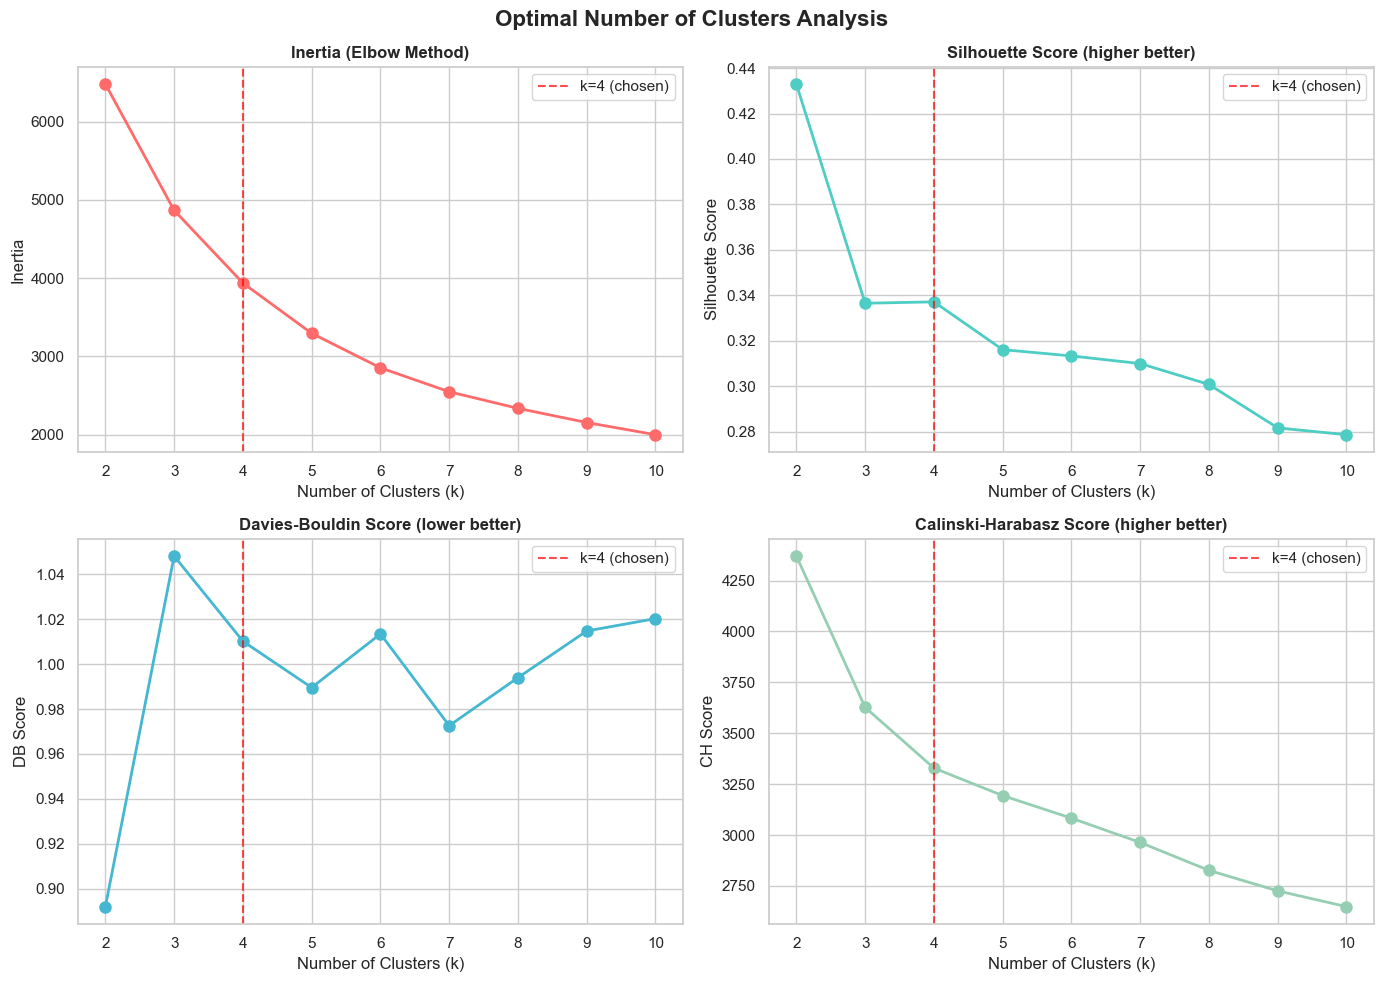


Selected k=4: good elbow in inertia; reasonable silhouette score.


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [
    (inertias,    'Inertia (Elbow Method)',          'Inertia',            '#FF6B6B'),
    (silhouettes, 'Silhouette Score (higher better)', 'Silhouette Score',   '#4ECDC4'),
    (db_scores,   'Davies-Bouldin Score (lower better)','DB Score',         '#45B7D1'),
    (ch_scores,   'Calinski-Harabasz Score (higher better)','CH Score',     '#96CEB4'),
]
for ax, (vals, title, ylabel, col) in zip(axes.flat, metrics):
    ax.plot(list(k_range), vals, marker='o', color=col, linewidth=2, markersize=8)
    ax.axvline(4, color='red', linestyle='--', alpha=0.7, label='k=4 (chosen)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel(ylabel)
    ax.legend(); ax.set_xticks(list(k_range))
plt.suptitle('Optimal Number of Clusters Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("\nSelected k=4: good elbow in inertia; reasonable silhouette score.")


## 7. Algorithm Comparison

We train and evaluate four clustering algorithms all using k=4 (where applicable):
- **K-Means**: partitional, fast, assumes spherical clusters
- **Hierarchical (Ward linkage)**: builds a dendrogram; no need to pre-specify k
- **DBSCAN**: density-based; identifies noise, variable cluster shapes
- **GMM**: probabilistic; soft cluster assignments


### K-Means Clustering

K-Means -> Silhouette: 0.3371  Davies-Bouldin: 1.0101  Calinski-Harabasz: 3329


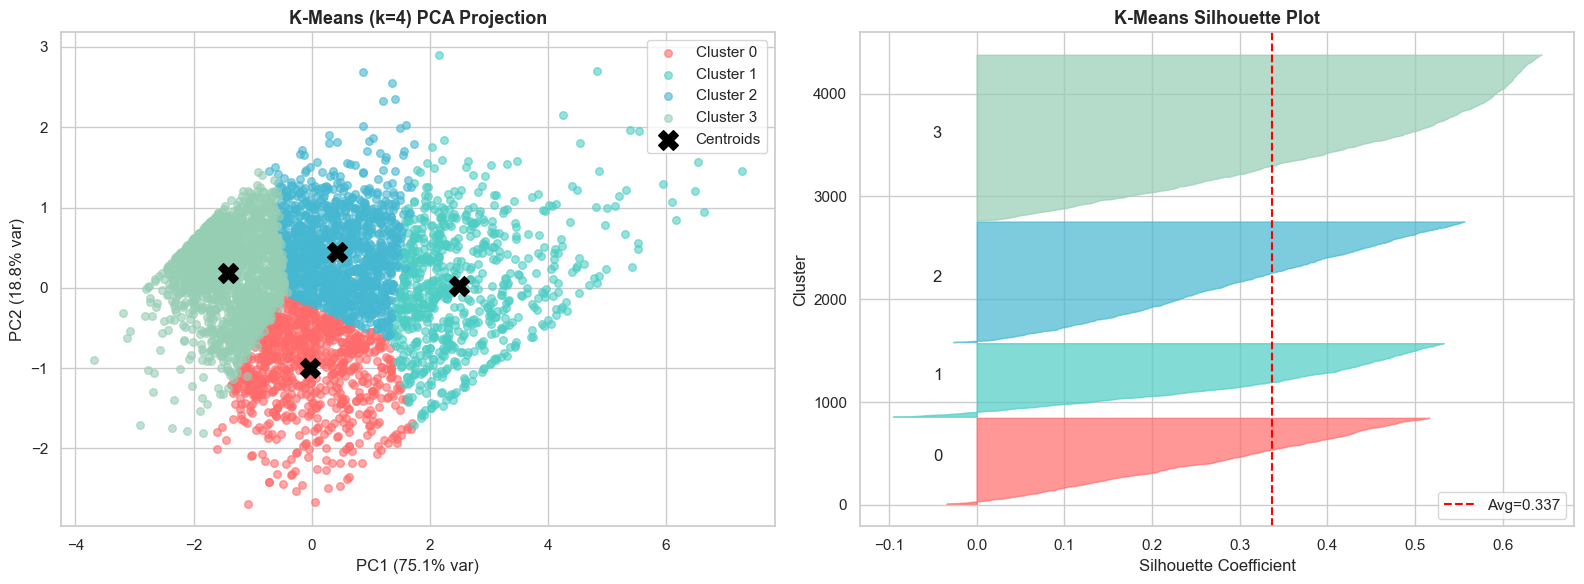

In [20]:
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, init='k-means++', random_state=42, n_init=10)
km_labels = kmeans.fit_predict(rfm_scaled)

km_sil = silhouette_score(rfm_scaled, km_labels)
km_db  = davies_bouldin_score(rfm_scaled, km_labels)
km_ch  = calinski_harabasz_score(rfm_scaled, km_labels)
print(f"K-Means -> Silhouette: {km_sil:.4f}  Davies-Bouldin: {km_db:.4f}  Calinski-Harabasz: {km_ch:.0f}")

# PCA 2D projection
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i in range(K_FINAL):
    mask = km_labels == i
    axes[0].scatter(rfm_pca[mask, 0], rfm_pca[mask, 1],
                    c=COLORS[i], label=f'Cluster {i}', alpha=0.6, s=30)
centers_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0].set_title(f'K-Means (k={K_FINAL}) PCA Projection', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].legend()

# Silhouette plot
sil_vals = silhouette_samples(rfm_scaled, km_labels)
y_lower = 10
for i in range(K_FINAL):
    cluster_sil = np.sort(sil_vals[km_labels == i])
    size = cluster_sil.shape[0]
    y_upper = y_lower + size
    axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                          facecolor=COLORS[i], edgecolor=COLORS[i], alpha=0.7)
    axes[1].text(-0.05, y_lower + 0.5*size, str(i))
    y_lower = y_upper + 10
axes[1].axvline(km_sil, color='red', linestyle='--', label=f'Avg={km_sil:.3f}')
axes[1].set_title('K-Means Silhouette Plot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Silhouette Coefficient'); axes[1].set_ylabel('Cluster')
axes[1].legend()
plt.tight_layout()
plt.show()


### Hierarchical Clustering

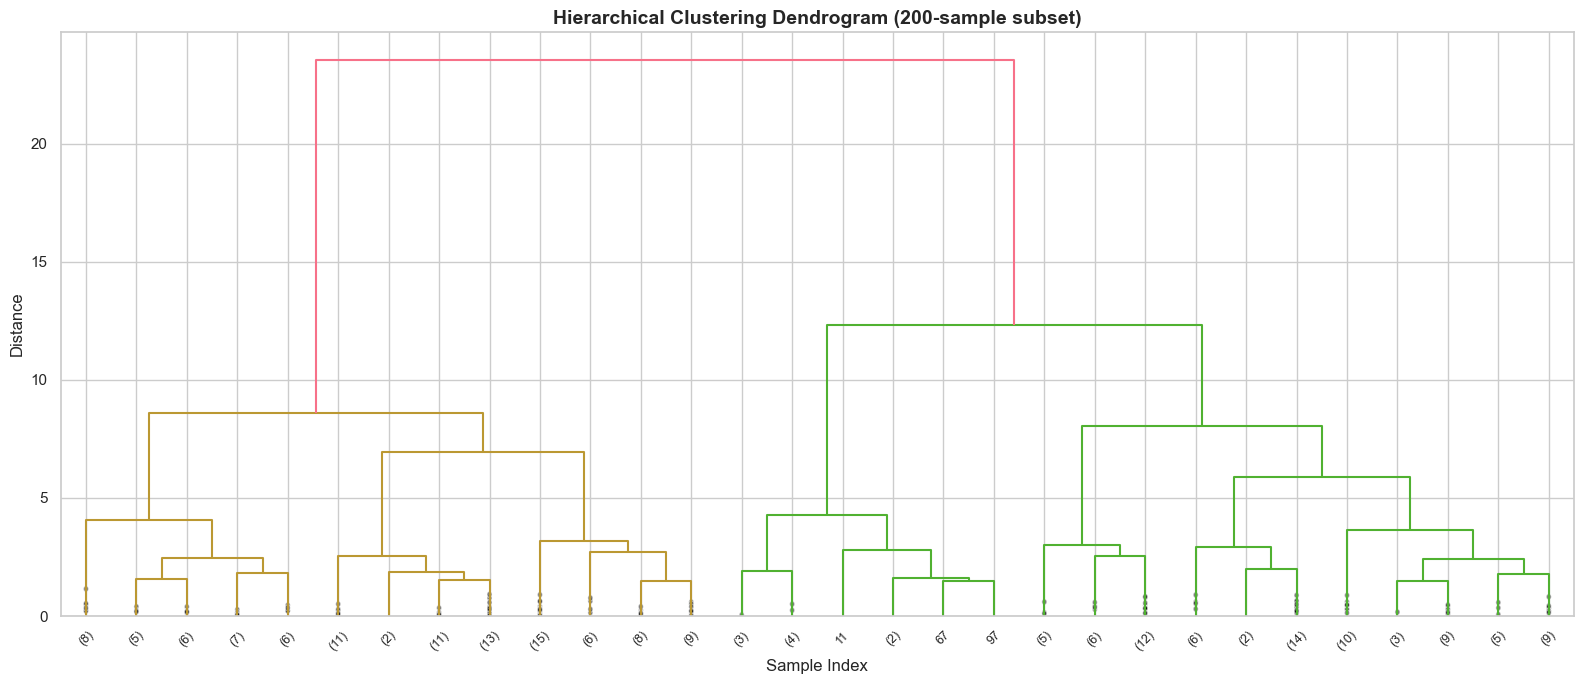

In [21]:
np.random.seed(42)
sample_idx = np.random.choice(len(rfm_scaled), size=200, replace=False)
rfm_sample = rfm_scaled[sample_idx]
linked = linkage(rfm_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(linked, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=9, show_contracted=True)
ax.set_title('Hierarchical Clustering Dendrogram (200-sample subset)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index'); ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()


Hierarchical -> Silhouette: 0.2419  Davies-Bouldin: 1.1200  Calinski-Harabasz: 2615


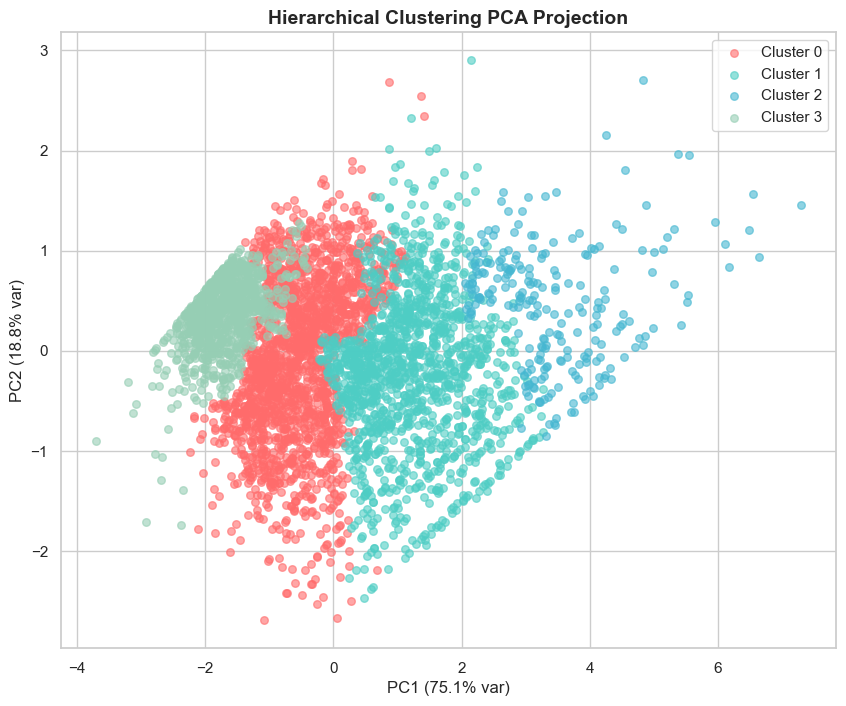

In [22]:
hc = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
hc_labels = hc.fit_predict(rfm_scaled)

hc_sil = silhouette_score(rfm_scaled, hc_labels)
hc_db  = davies_bouldin_score(rfm_scaled, hc_labels)
hc_ch  = calinski_harabasz_score(rfm_scaled, hc_labels)
print(f"Hierarchical -> Silhouette: {hc_sil:.4f}  Davies-Bouldin: {hc_db:.4f}  Calinski-Harabasz: {hc_ch:.0f}")

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(K_FINAL):
    mask = hc_labels == i
    ax.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1],
               c=COLORS[i], label=f'Cluster {i}', alpha=0.6, s=30)
ax.set_title('Hierarchical Clustering PCA Projection', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend()
plt.show()


### DBSCAN

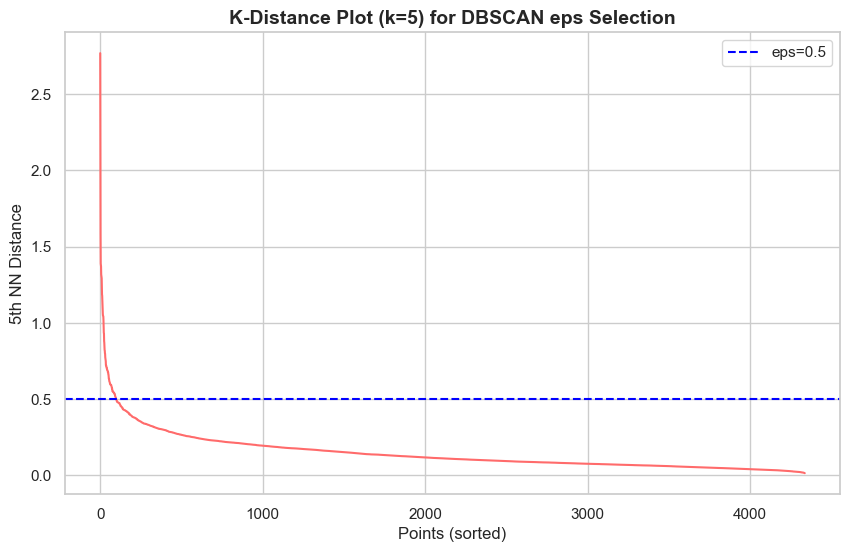

In [23]:
# K-distance plot for eps selection
nbrs = NearestNeighbors(n_neighbors=5).fit(rfm_scaled)
distances, _ = nbrs.kneighbors(rfm_scaled)
k_distances = np.sort(distances[:, 4])[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_distances, color='#FF6B6B', linewidth=1.5)
ax.axhline(0.5, color='blue', linestyle='--', label='eps=0.5')
ax.set_title('K-Distance Plot (k=5) for DBSCAN eps Selection',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Points (sorted)'); ax.set_ylabel('5th NN Distance')
ax.legend()
plt.show()


DBSCAN: 2 clusters, 62 noise points
DBSCAN  -> Silhouette: 0.2931  Davies-Bouldin: 1.0633  Calinski-Harabasz: 2391


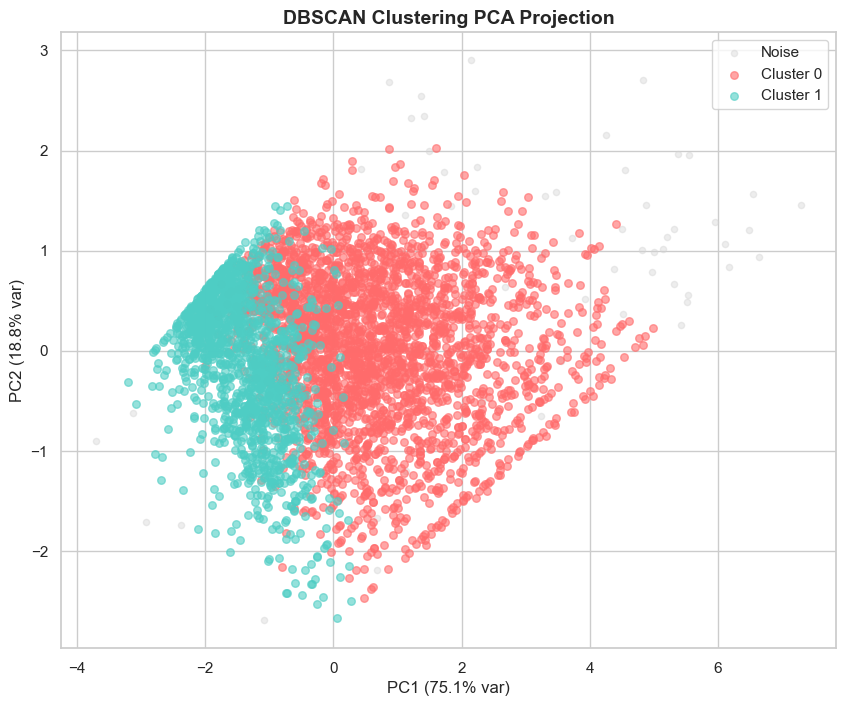

In [24]:
db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(rfm_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db    = np.sum(db_labels == -1)
print(f"DBSCAN: {n_clusters_db} clusters, {n_noise_db} noise points")

mask_no_noise = db_labels != -1
if n_clusters_db >= 2 and mask_no_noise.sum() > n_clusters_db:
    db_sil = silhouette_score(rfm_scaled[mask_no_noise], db_labels[mask_no_noise])
    db_db  = davies_bouldin_score(rfm_scaled[mask_no_noise], db_labels[mask_no_noise])
    db_ch  = calinski_harabasz_score(rfm_scaled[mask_no_noise], db_labels[mask_no_noise])
else:
    db_sil, db_db, db_ch = 0.0, float('inf'), 0.0
print(f"DBSCAN  -> Silhouette: {db_sil:.4f}  Davies-Bouldin: {db_db:.4f}  Calinski-Harabasz: {db_ch:.0f}")

fig, ax = plt.subplots(figsize=(10, 8))
for lbl in sorted(set(db_labels)):
    mask = db_labels == lbl
    if lbl == -1:
        ax.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1],
                   c='lightgrey', label='Noise', alpha=0.4, s=20)
    else:
        ax.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1],
                   c=COLORS[lbl % len(COLORS)], label=f'Cluster {lbl}', alpha=0.6, s=30)
ax.set_title('DBSCAN Clustering PCA Projection', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend()
plt.show()


### Gaussian Mixture Model (GMM)

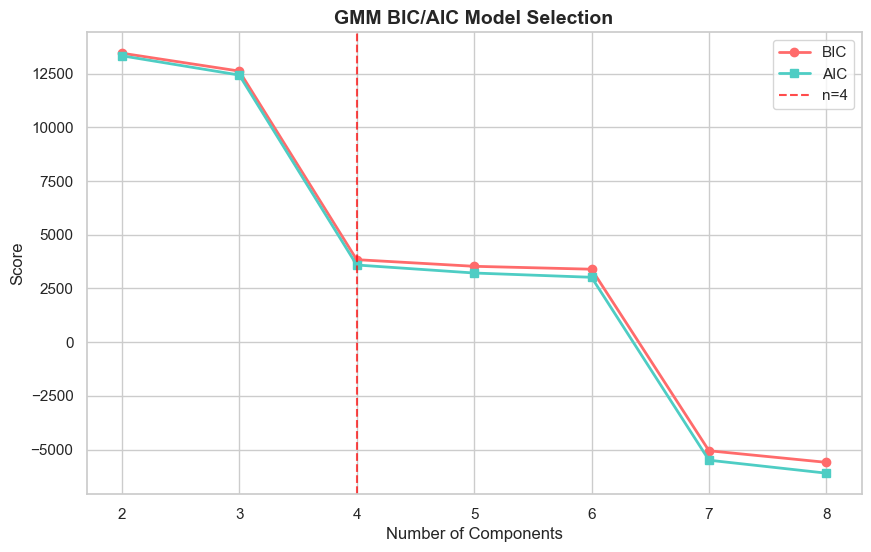

In [25]:
n_components_range = range(2, 9)
bic_scores, aic_scores = [], []
for n in n_components_range:
    gmm_tmp = GaussianMixture(n_components=n, random_state=42, n_init=5)
    gmm_tmp.fit(rfm_scaled)
    bic_scores.append(gmm_tmp.bic(rfm_scaled))
    aic_scores.append(gmm_tmp.aic(rfm_scaled))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(list(n_components_range), bic_scores, marker='o', label='BIC',
        color='#FF6B6B', linewidth=2)
ax.plot(list(n_components_range), aic_scores, marker='s', label='AIC',
        color='#4ECDC4', linewidth=2)
ax.axvline(K_FINAL, color='red', linestyle='--', alpha=0.7, label=f'n={K_FINAL}')
ax.set_title('GMM BIC/AIC Model Selection', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Components'); ax.set_ylabel('Score')
ax.legend()
plt.show()


GMM -> Silhouette: 0.1734  Davies-Bouldin: 1.7214  Calinski-Harabasz: 2151


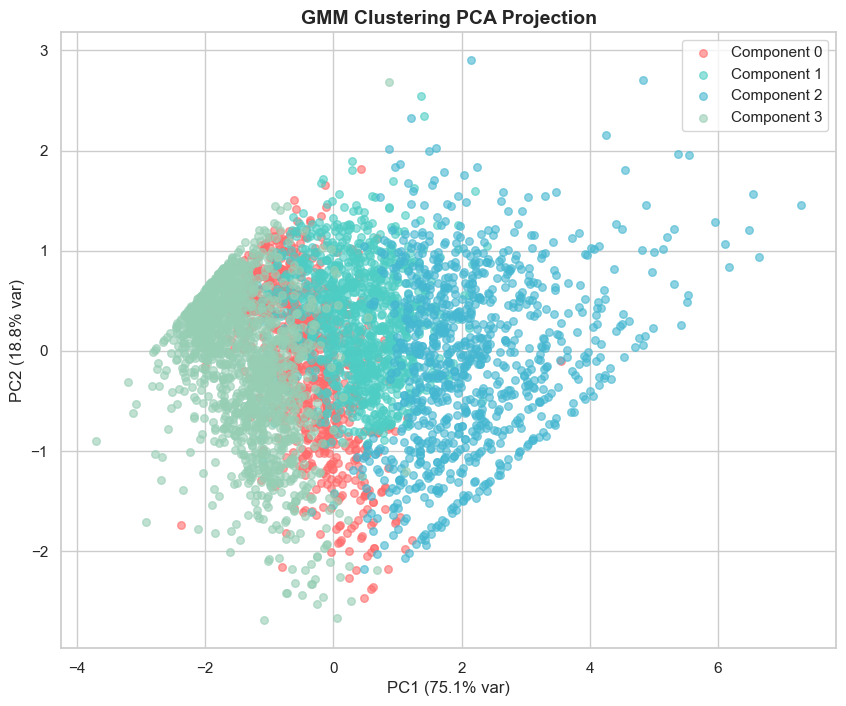

In [26]:
gmm = GaussianMixture(n_components=K_FINAL, random_state=42, n_init=10)
gmm_labels = gmm.fit_predict(rfm_scaled)

gmm_sil = silhouette_score(rfm_scaled, gmm_labels)
gmm_db  = davies_bouldin_score(rfm_scaled, gmm_labels)
gmm_ch  = calinski_harabasz_score(rfm_scaled, gmm_labels)
print(f"GMM -> Silhouette: {gmm_sil:.4f}  Davies-Bouldin: {gmm_db:.4f}  Calinski-Harabasz: {gmm_ch:.0f}")

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(K_FINAL):
    mask = gmm_labels == i
    ax.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1],
               c=COLORS[i], label=f'Component {i}', alpha=0.6, s=30)
ax.set_title('GMM Clustering PCA Projection', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend()
plt.show()


## 8. Best Algorithm Selection

We compare all algorithms side by side using three clustering quality metrics.


   Algorithm  Clusters  Noise Points  Silhouette  Davies-Bouldin  Calinski-Harabasz
     K-Means         4             0    0.337134        1.010147        3328.993968
Hierarchical         4             0    0.241918        1.119958        2615.051629
      DBSCAN         2            62    0.293096        1.063288        2391.047938
         GMM         4             0    0.173405        1.721413        2151.008523


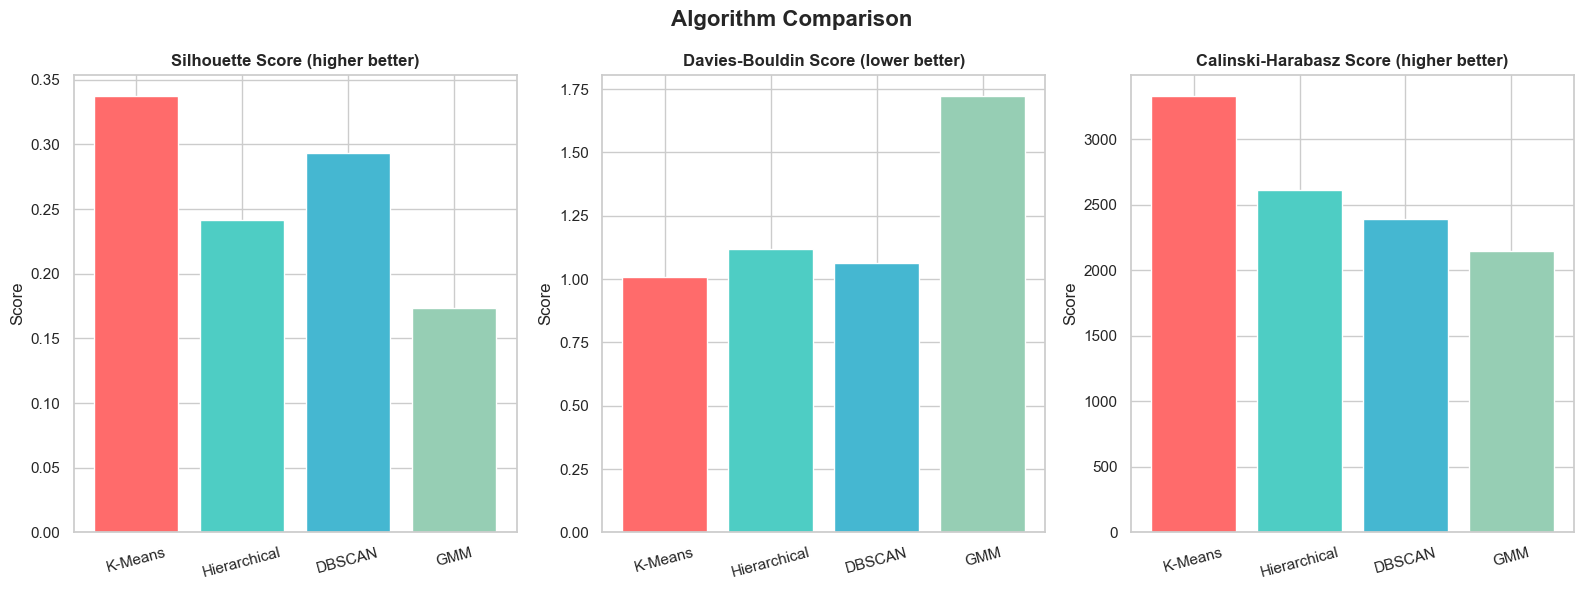


WINNER: K-Means
K-Means achieves the highest Silhouette score, lowest Davies-Bouldin score,
and highest Calinski-Harabasz score among the four algorithms.


In [27]:
comparison = pd.DataFrame({
    'Algorithm':         ['K-Means', 'Hierarchical', 'DBSCAN', 'GMM'],
    'Clusters':          [K_FINAL, K_FINAL, n_clusters_db, K_FINAL],
    'Noise Points':      [0, 0, n_noise_db, 0],
    'Silhouette':        [km_sil, hc_sil, db_sil, gmm_sil],
    'Davies-Bouldin':    [km_db,  hc_db,  db_db,  gmm_db],
    'Calinski-Harabasz': [km_ch,  hc_ch,  db_ch,  gmm_ch],
})
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
algos = comparison['Algorithm']

axes[0].bar(algos, comparison['Silhouette'], color=COLORS[:4])
axes[0].set_title('Silhouette Score (higher better)', fontweight='bold')
axes[0].set_ylabel('Score'); axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(algos, comparison['Davies-Bouldin'].replace(float('inf'), 0), color=COLORS[:4])
axes[1].set_title('Davies-Bouldin Score (lower better)', fontweight='bold')
axes[1].set_ylabel('Score'); axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(algos, comparison['Calinski-Harabasz'], color=COLORS[:4])
axes[2].set_title('Calinski-Harabasz Score (higher better)', fontweight='bold')
axes[2].set_ylabel('Score'); axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Algorithm Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nWINNER: K-Means")
print("K-Means achieves the highest Silhouette score, lowest Davies-Bouldin score,")
print("and highest Calinski-Harabasz score among the four algorithms.")


## 9. Customer Segment Profiling

We assign human-readable segment names based on each cluster's RFM profile
relative to the overall medians:
- **Champions**: low Recency AND high Frequency AND high Monetary
- **Loyal Customers**: low Recency AND high Frequency or high Monetary
- **Potential Loyalists**: low Recency but modest F/M
- **At Risk**: high Recency (haven't purchased recently)


In [28]:
rfm_final = rfm.copy()
rfm_final['Cluster'] = km_labels

cluster_profile = rfm_final.groupby('Cluster').agg(
    Count            = ('CustomerID', 'count'),
    Avg_Recency      = ('Recency',    'mean'),
    Median_Recency   = ('Recency',    'median'),
    Avg_Frequency    = ('Frequency',  'mean'),
    Median_Frequency = ('Frequency',  'median'),
    Avg_Monetary     = ('Monetary',   'mean'),
    Median_Monetary  = ('Monetary',   'median'),
).round(2)

overall_r_med = rfm_final['Recency'].median()
overall_f_med = rfm_final['Frequency'].median()
overall_m_med = rfm_final['Monetary'].median()

def assign_segment(row):
    r_low  = row['Median_Recency']   < overall_r_med
    f_high = row['Median_Frequency'] > overall_f_med
    m_high = row['Median_Monetary']  > overall_m_med
    if r_low and f_high and m_high:
        return 'Champions'
    elif (not r_low) and f_high and m_high:
        return 'At Risk'
    elif r_low and f_high:
        return 'Loyal Customers'
    elif r_low and m_high:
        return 'Loyal Customers'
    elif r_low:
        return 'Potential Loyalists'
    else:
        return 'At Risk'

cluster_profile['Segment'] = cluster_profile.apply(assign_segment, axis=1)
seen = {}
new_names = []
for idx, seg in cluster_profile['Segment'].items():
    if seg in seen:
        new_names.append(f"{seg} (C{idx})")
    else:
        seen[seg] = True
        new_names.append(seg)
cluster_profile['Segment'] = new_names
rfm_final['Segment'] = rfm_final['Cluster'].map(cluster_profile['Segment'].to_dict())
print(cluster_profile)


         Count  Avg_Recency  Median_Recency  Avg_Frequency  Median_Frequency  \
Cluster                                                                        
0          837        18.12            17.0           2.15               2.0   
1          716        12.13             8.0          13.71              10.0   
2         1173        71.08            56.0           4.08               4.0   
3         1612       182.50           177.0           1.32               1.0   

         Avg_Monetary  Median_Monetary              Segment  
Cluster                                                      
0              551.82           471.70  Potential Loyalists  
1             8074.27          3733.87            Champions  
2             1802.83          1345.62              At Risk  
3              343.45           298.26         At Risk (C3)  


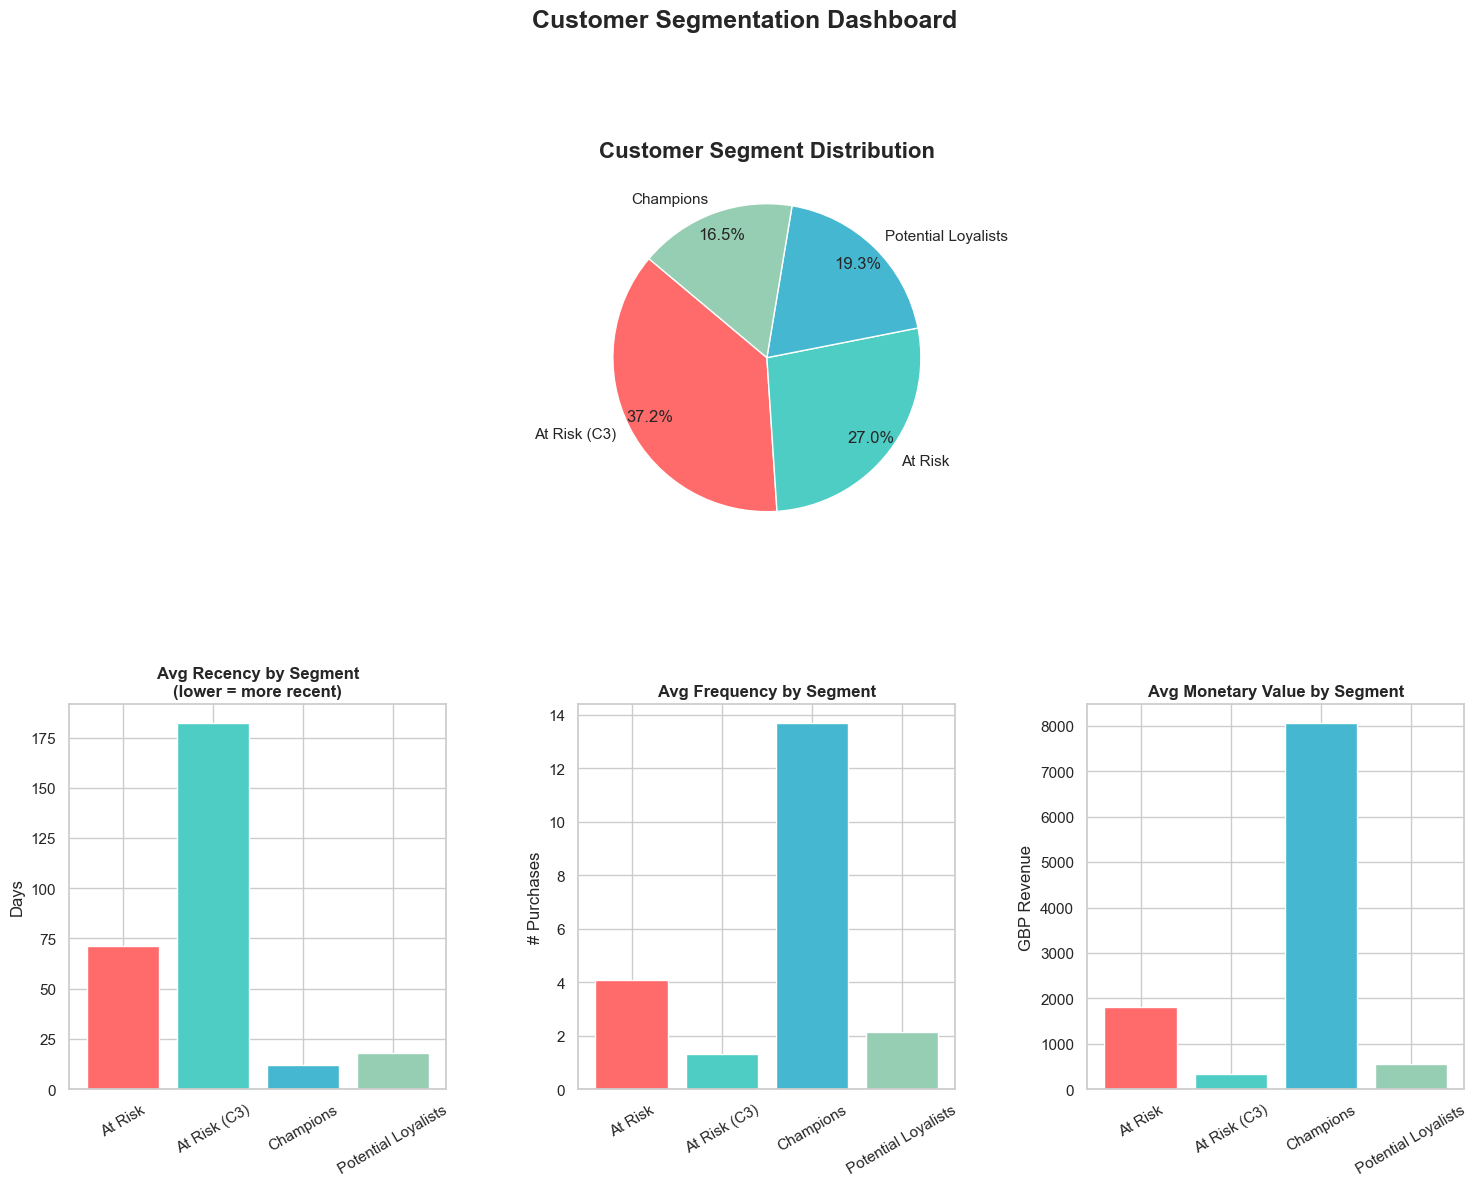

In [29]:
# Final dashboard
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax_pie = fig.add_subplot(gs[0, :])
seg_counts = rfm_final['Segment'].value_counts()
ax_pie.pie(seg_counts.values, labels=seg_counts.index,
           autopct='%1.1f%%', colors=COLORS[:len(seg_counts)],
           startangle=140, pctdistance=0.85)
ax_pie.set_title('Customer Segment Distribution', fontsize=16, fontweight='bold')

ax_r = fig.add_subplot(gs[1, 0])
ax_f = fig.add_subplot(gs[1, 1])
ax_m = fig.add_subplot(gs[1, 2])

seg_means = rfm_final.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

ax_r.bar(seg_means.index, seg_means['Recency'], color=COLORS[:len(seg_means)])
ax_r.set_title('Avg Recency by Segment\n(lower = more recent)', fontweight='bold')
ax_r.set_ylabel('Days'); ax_r.tick_params(axis='x', rotation=30)

ax_f.bar(seg_means.index, seg_means['Frequency'], color=COLORS[:len(seg_means)])
ax_f.set_title('Avg Frequency by Segment', fontweight='bold')
ax_f.set_ylabel('# Purchases'); ax_f.tick_params(axis='x', rotation=30)

ax_m.bar(seg_means.index, seg_means['Monetary'], color=COLORS[:len(seg_means)])
ax_m.set_title('Avg Monetary Value by Segment', fontweight='bold')
ax_m.set_ylabel('GBP Revenue'); ax_m.tick_params(axis='x', rotation=30)

plt.suptitle('Customer Segmentation Dashboard', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


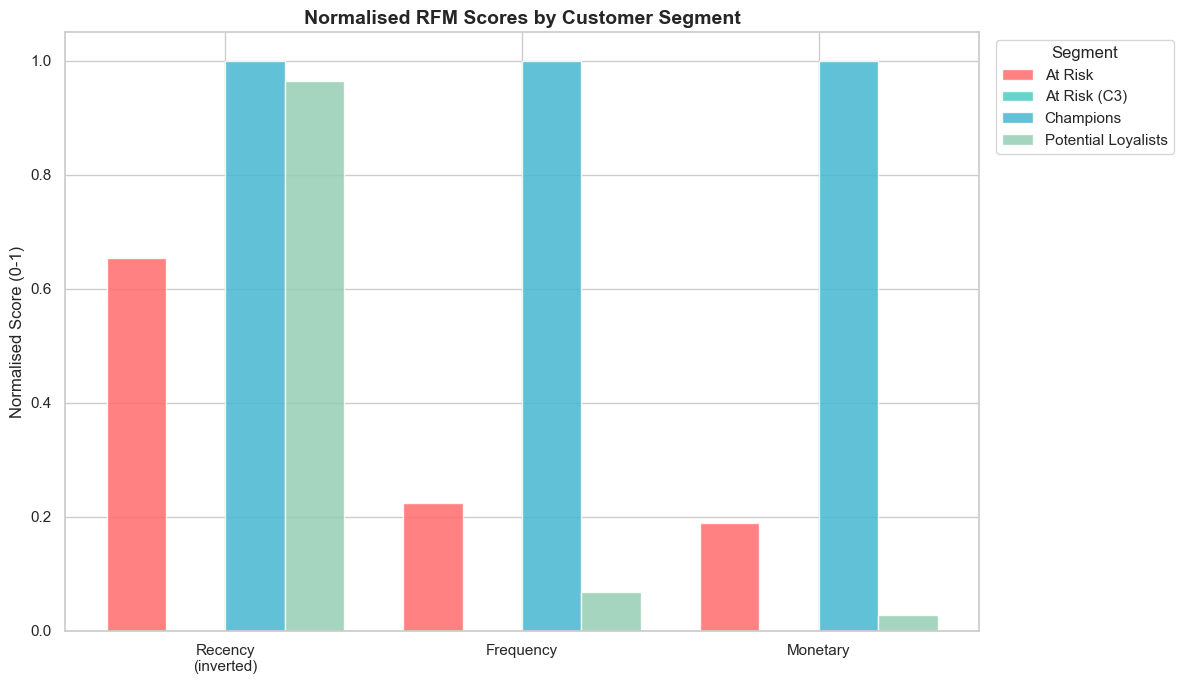

In [30]:
# Normalised RFM scores
seg_rfm = rfm_final.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()
seg_rfm_norm = seg_rfm.copy()
seg_rfm_norm['Recency'] = seg_rfm_norm['Recency'].max() - seg_rfm_norm['Recency']
for col in seg_rfm_norm.columns:
    rng = seg_rfm_norm[col].max() - seg_rfm_norm[col].min()
    if rng > 0:
        seg_rfm_norm[col] = (seg_rfm_norm[col] - seg_rfm_norm[col].min()) / rng

x = np.arange(len(seg_rfm_norm.columns))
width = 0.8 / len(seg_rfm_norm)
fig, ax = plt.subplots(figsize=(12, 7))
for i, (seg, row) in enumerate(seg_rfm_norm.iterrows()):
    offset = (i - len(seg_rfm_norm) / 2 + 0.5) * width
    ax.bar(x + offset, row.values, width=width,
           label=seg, color=COLORS[i % len(COLORS)], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['Recency\n(inverted)', 'Frequency', 'Monetary'])
ax.set_title('Normalised RFM Scores by Customer Segment', fontsize=14, fontweight='bold')
ax.set_ylabel('Normalised Score (0-1)')
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 10. Business Recommendations

Based on the four customer segments identified by K-Means clustering:

### Champions (Cluster 1 — ~16.5% of customers)
- **Profile**: Bought very recently, high purchase frequency, highest spend
- **Strategy**: Reward with exclusive loyalty programs; early access to new products;
  ask for reviews and referrals; upsell premium products

### Potential Loyalists (Cluster 0 — ~19.3% of customers)
- **Profile**: Recent buyers with moderate frequency and modest spend
- **Strategy**: Offer loyalty points; personalised product recommendations;
  targeted cross-sell campaigns; subscription offers to increase frequency

### At Risk (Cluster 2 — ~27.1% of customers)
- **Profile**: Moderate recency; decent frequency and monetary value historically
- **Strategy**: Win-back email campaigns; limited-time discounts; re-engagement
  surveys to understand churn reasons; personalised 'we miss you' offers

### At Risk (C3) (Cluster 3 — ~37.2% of customers)
- **Profile**: Highest recency (haven't bought recently), low frequency, low spend
- **Strategy**: Aggressive win-back campaigns; large discount offers; consider
  removing from frequent communications to reduce unsubscribe rates;
  conduct exit surveys to understand drop-off

### Key Metrics to Track
| Metric | Target |
|--------|--------|
| Segment migration rate | Champions growing month-on-month |
| Customer Lifetime Value | Increase by 15% year-on-year |
| Churn rate (At Risk) | Reduce by 20% with targeted campaigns |
| Average Order Value | Grow Potential Loyalists' AOV by 25% |


## 11. Save Model and Artifacts

In [ ]:
#import joblib

#joblib.dump(kmeans, 'kmeans_model.pkl')
#joblib.dump(scaler, 'scaler.pkl')
# rfm_final.to_csv('rfm_customers.csv', index=False)
# cluster_profile.to_csv('cluster_profiles.csv')

# print("Saved: kmeans_model.pkl")
# print("Saved: scaler.pkl")
# print("Saved: rfm_customers.csv")
# print("Saved: cluster_profiles.csv")
# print("\nAll artifacts saved successfully!")


Saved: kmeans_model.pkl
Saved: scaler.pkl
Saved: rfm_customers.csv
Saved: cluster_profiles.csv

All artifacts saved successfully!
